# Risky choice with lapses — two psychometric models

This notebook fits two psychometric models with lapses to Alina's
gain/loss pilot data and compares them. Both regress noise + lapse on
domain so we can read off any gain/loss difference directly.

| Model | Module                                     | Notes |
|-------|--------------------------------------------|-------|
| Simple log-EU psychometric    | `PsychophysicalLapseRegressionModel` | Single `nu` (no order effect), explicit `bias` risk-premium parameter. Fast. |
| Bayesian observer + lapse    | `RiskLapseRegressionModel`         | Separate `n1_evidence_sd` / `n2_evidence_sd` capture working-memory order effects. Risk attitudes via prior shrinkage (KLW). |

## Two data conventions

1. **Keep `n1, n2, p1, p2` in presentation order.** Bauer infers
   which is the gamble from `p1 < p2`; keeping the original order lets
   `n1_evidence_sd ≠ n2_evidence_sd` absorb working-memory effects.
2. **Flip `choice` on loss trials.** Gains ask "pick the larger EV";
   losses ask "pick the smaller |EV|" — exact opposites. Flipping
   `choice` in losses aligns these into a single drift formula. After
   the flip, `choice = True` ⟺ "took the EV-improving action" in both
   domains, and the psychometric slope (going up with $\log(EU_2/EU_1)$)
   is consistent across domains.

The fits themselves are run on the cluster via
`slurm/run_psychometric_{simple,bayes}.sh`. This notebook only reads the
saved `InferenceData` files.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from helpers import (prepare, natural_summary, per_subject_summary,
                     plot_forest, plot_contrast, plot_subject_panels,
                     chose_risky, log_risky_safe, mark_ev_neutral,
                     GAIN, LOSS, CONDITIONS)

HERE = Path(__file__).parent if '__file__' in dir() else Path('.').resolve()
if not (HERE / 'data' / 'pilot_data.tsv').exists() and (HERE / 'for_alina').exists():
    HERE = HERE / 'for_alina'

df_raw = pd.read_csv(HERE / 'data' / 'pilot_data.tsv', sep='\t').set_index(['subject', 'trial'])
print(f'{df_raw.index.get_level_values("subject").nunique()} subjects, {len(df_raw)} trials')
print('\nP(chose risky) by domain:')
df_raw_with_risky = df_raw.assign(chose_risky=chose_risky(df_raw))
print(df_raw_with_risky.groupby('domain')['chose_risky'].mean().round(3))

2 subjects, 798 trials

P(chose risky) by domain:
domain
gain    0.602
loss    0.638
Name: chose_risky, dtype: float64


## Raw data

Both subjects in the pilot are slightly **risk-seeking** in gains *and*
in losses (P(chose risky) ≈ 0.60 in both domains). With only two pilots
the group-level estimates will be wide — per-subject values are more
informative.

Below: the psychometric data plotted on the `log(risky / safe)` axis
shows the **opposite slope directions** between domains (decreasing in
losses because bigger risky = bigger loss = less attractive). After
flipping `choice` in losses the model sees one consistent slope.

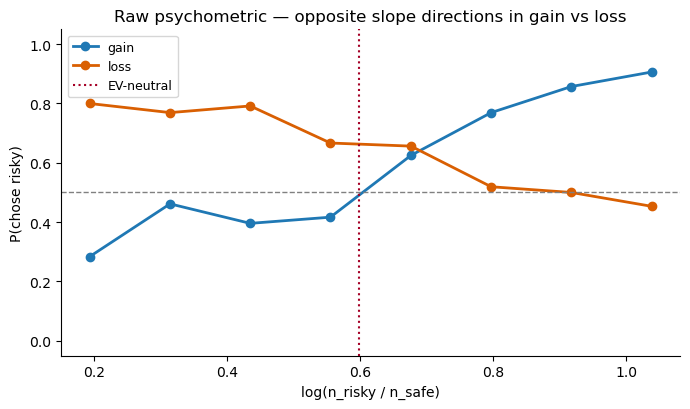

In [2]:
df_plot = df_raw_with_risky.reset_index()
df_plot['log_ratio'] = log_risky_safe(df_plot)
df_plot['bin'] = pd.cut(df_plot['log_ratio'], bins=8).map(lambda x: x.mid).astype(float)

grouped = (df_plot.groupby(['domain', 'bin'])
                  .agg(p=('chose_risky', 'mean'), n=('chose_risky', 'size'))
                  .reset_index()
                  .query('n >= 10'))

fig, ax = plt.subplots(figsize=(7, 4.2))
for dom, c in [('gain', GAIN), ('loss', LOSS)]:
    d = grouped[grouped['domain'] == dom]
    ax.plot(d['bin'], d['p'], 'o-', color=c, lw=2, label=dom)
ax.axhline(0.5, ls='--', c='gray', lw=1)
mark_ev_neutral(ax)
ax.set_xlabel('log(n_risky / n_safe)'); ax.set_ylabel('P(chose risky)')
ax.set_title('Raw psychometric — opposite slope directions in gain vs loss')
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9); sns.despine()
plt.tight_layout()

## Fit the models

Both fit scripts call `helpers.prepare()` to flip the loss-trial choice,
build the regression model, sample with `numpyro`, and write the
`.nc` file.

```bash
# Local sanity check
python fit_psychometric_simple.py --draws 200 --tune 200 --backend pymc
python fit_psychometric_bayes.py  --draws 200 --tune 200 --backend pymc

# Cluster
ssh sciencecluster '
    cd ~/git/bauer/examples/for_alina &&
    sbatch slurm/run_psychometric_simple.sh &&
    sbatch slurm/run_psychometric_bayes.sh'
rsync sciencecluster:git/bauer/examples/for_alina/results/*.nc ./results/
```

In [3]:
from bauer.models import PsychophysicalLapseRegressionModel, RiskLapseRegressionModel
from fit_psychometric_simple import prepare as prep_simple

df_simple = prep_simple(df_raw)   # adds x1=log(EU1), x2=log(EU2), flips choice
df_bayes  = prepare(df_raw)        # just flips choice; keeps n1/n2/p1/p2

m_simple = PsychophysicalLapseRegressionModel(
    paradigm=df_simple.reset_index(),
    regressors={'nu': 'C(domain)', 'bias': 'C(domain)', 'p_lapse': 'C(domain)'},
)
m_simple.build_estimation_model(data=df_simple, hierarchical=True)
idata_simple = az.from_netcdf(HERE / 'results' / 'psychometric_simple_idata.nc')

m_bayes = RiskLapseRegressionModel(
    paradigm=df_bayes.reset_index(),
    regressors={'n1_evidence_sd': 'C(domain)',
                'n2_evidence_sd': 'C(domain)',
                'p_lapse':        'C(domain)'},
    prior_estimate='full',
)
m_bayes.build_estimation_model(data=df_bayes, hierarchical=True)
idata_bayes = az.from_netcdf(HERE / 'results' / 'psychometric_bayes_idata.nc')

# Quick convergence check
for name, idata in [('Simple', idata_simple), ('Bayes', idata_bayes)]:
    s = az.summary(idata, var_names=[v for v in idata.posterior.data_vars
                                      if v.endswith('_mu') and not v.endswith('_mu_mu')],
                   round_to=3)
    print(f'{name}: max r̂={s["r_hat"].max():.3f}, min ESS={s["ess_bulk"].min():.0f}')

Simple: max r̂=1.003, min ESS=1425
Bayes: max r̂=1.036, min ESS=104


## Group-level estimates on the natural scale

Parameters on bauer's transformed scale aren't immediately interpretable;
`helpers.natural_summary` applies the link function and reports the
posterior **mean** with a 94 % HDI per (parameter × domain).

In [4]:
simple_summary = natural_summary(m_simple, idata_simple, ['nu', 'bias', 'p_lapse'])
bayes_summary  = natural_summary(m_bayes,  idata_bayes,
                                  ['n1_evidence_sd', 'n2_evidence_sd', 'p_lapse'])

print('=== Simple model ===');  print(simple_summary.set_index(['parameter','domain']).round(4))
print('\n=== Bayesian model ==='); print(bayes_summary.set_index(['parameter','domain']).round(4))

=== Simple model ===
                    mean  hdi_lo  hdi_hi
parameter domain                        
nu        gain    0.3393  0.2009  0.4810
          loss    0.5776  0.0864  1.1382
bias      gain   -0.1007 -0.4510  0.2089
          loss   -0.1385 -0.7239  0.5211
p_lapse   gain    0.0305  0.0011  0.0877
          loss    0.0546  0.0002  0.1991

=== Bayesian model ===
                         mean  hdi_lo  hdi_hi
parameter      domain                        
n1_evidence_sd gain    0.3049  0.1560  0.4645
               loss    0.6054  0.0365  1.2386
n2_evidence_sd gain    0.2838  0.0652  0.6475
               loss    0.5032  0.0075  1.4055
p_lapse        gain    0.0361  0.0008  0.0956
               loss    0.0505  0.0002  0.1674


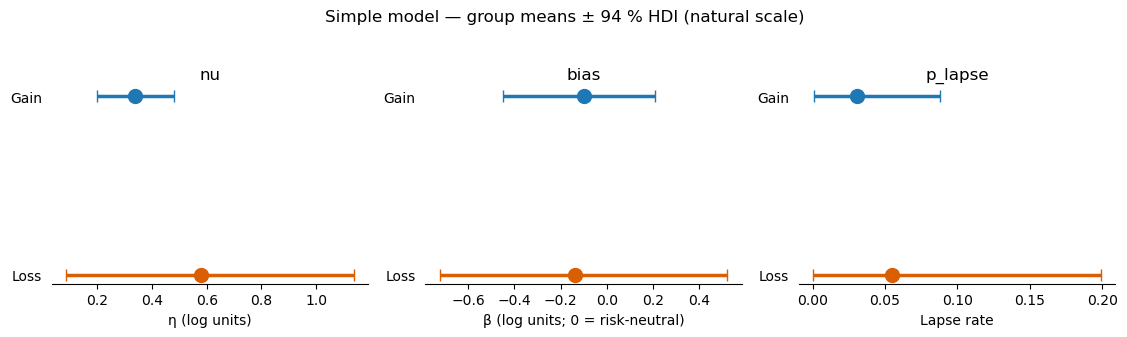

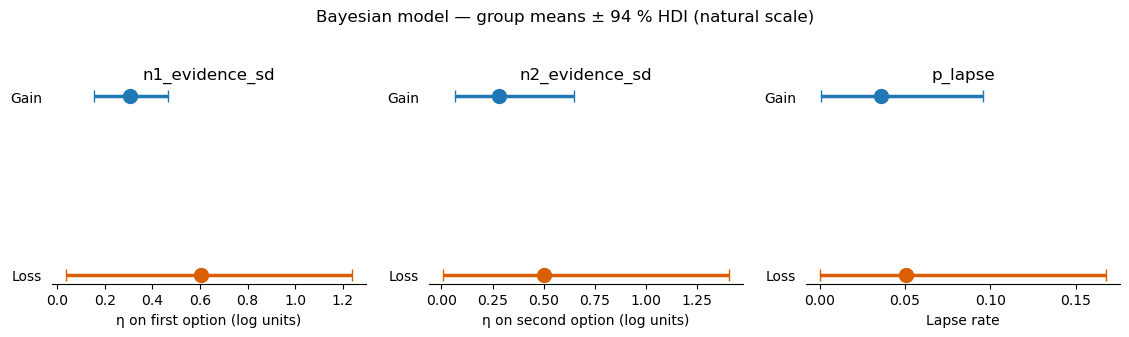

In [5]:
plot_forest(simple_summary,
            'Simple model — group means ± 94 % HDI (natural scale)',
            scale_hints={'nu':      'η (log units)',
                         'bias':    'β (log units; 0 = risk-neutral)',
                         'p_lapse': 'Lapse rate'})

plot_forest(bayes_summary,
            'Bayesian model — group means ± 94 % HDI (natural scale)',
            scale_hints={'n1_evidence_sd': 'η on first option (log units)',
                         'n2_evidence_sd': 'η on second option (log units)',
                         'p_lapse':        'Lapse rate'})

## Gain − loss contrast

KDE of the per-parameter loss − gain contrast on the natural scale,
with the posterior mean and 94 % HDI annotated.

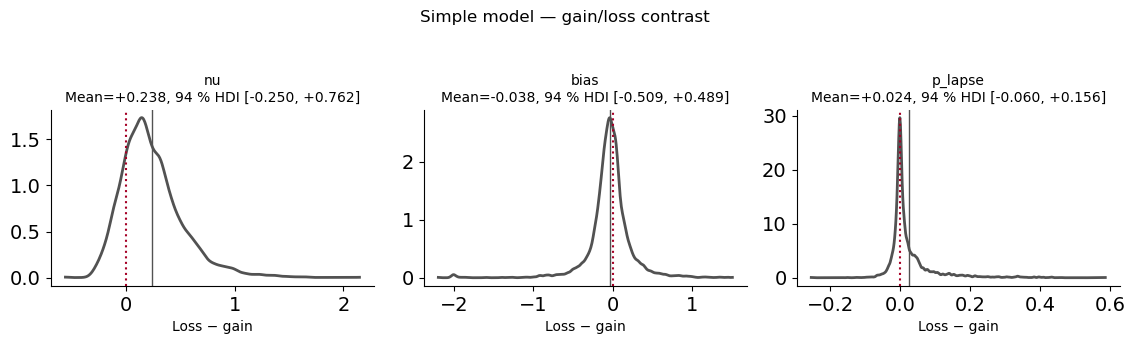

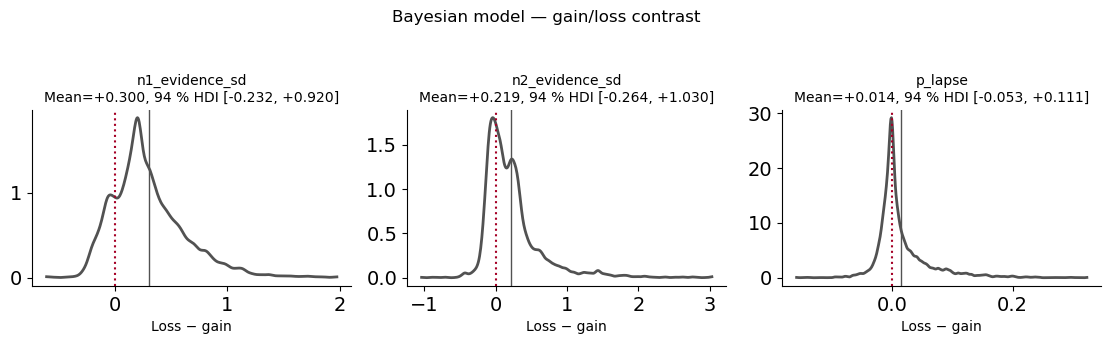

In [6]:
plot_contrast(m_simple, idata_simple,
              ['nu', 'bias', 'p_lapse'],
              'Simple model — gain/loss contrast')
plot_contrast(m_bayes, idata_bayes,
              ['n1_evidence_sd', 'n2_evidence_sd', 'p_lapse'],
              'Bayesian model — gain/loss contrast')

## Per-subject estimates

Hierarchical fitting gives a full posterior per subject. With only two
pilot subjects, these are visible explicitly.

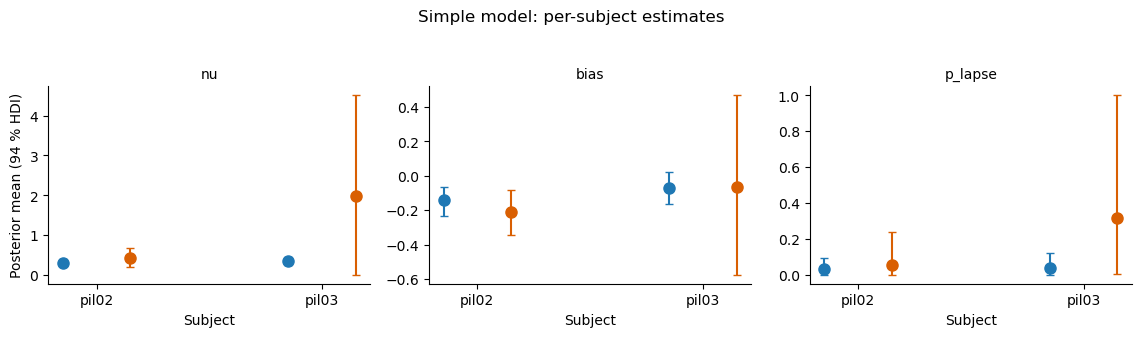

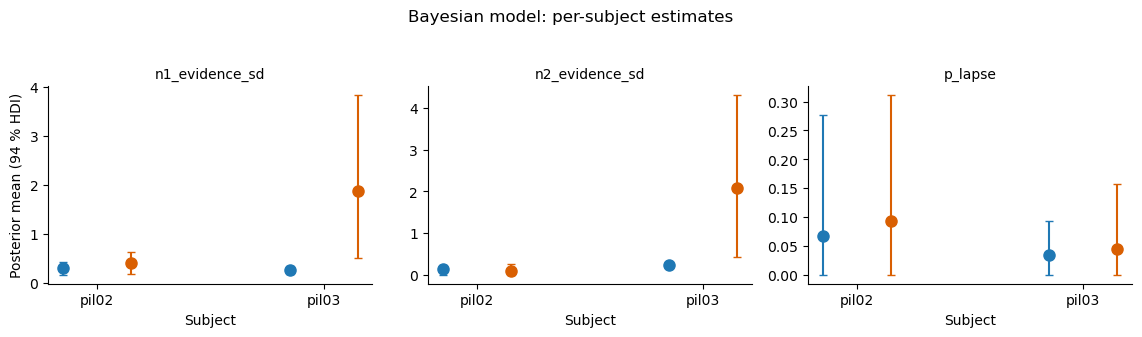

In [7]:
plot_subject_panels(per_subject_summary(m_simple, idata_simple,
                                         ['nu', 'bias', 'p_lapse']),
                    'Simple model: per-subject estimates')
plot_subject_panels(per_subject_summary(m_bayes, idata_bayes,
                                         ['n1_evidence_sd', 'n2_evidence_sd',
                                          'p_lapse']),
                    'Bayesian model: per-subject estimates')

## Posterior predictive check (Bayesian model)

Draw 200 posterior-predictive datasets, convert `simulated_choice`
back to **P(chose risky)** per trial, and overlay the 94 % HDI band on
binned observed data, separately per domain.

Sampling: [ll_bernoulli]


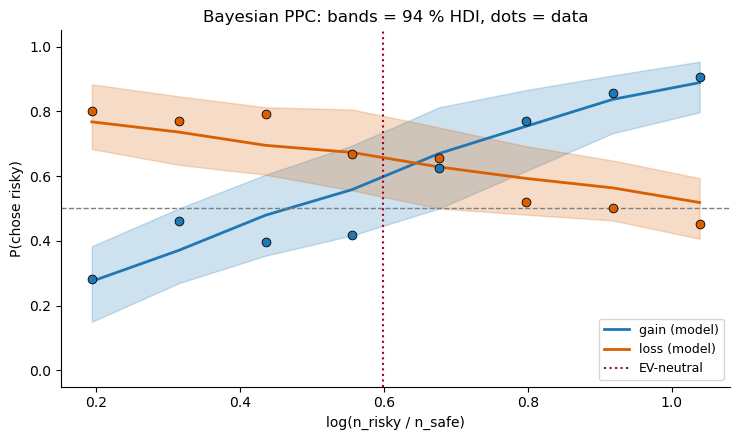

In [8]:
ppc = m_bayes.ppc(df_bayes, idata_bayes, n_posterior_samples=200,
                   progressbar=False)
ppc_join = ppc.join(df_bayes[['n1', 'n2', 'p1', 'p2', 'domain']], how='left')
ppc_join['log_ratio'] = log_risky_safe(ppc_join)
ppc_join['sim_chose_risky'] = chose_risky(ppc_join, 'simulated_choice', flipped=True)

# Use shared bin edges
bin_edges = np.linspace(ppc_join['log_ratio'].min(),
                        ppc_join['log_ratio'].max(), 9)
def _bin(x): return pd.cut(x, bins=bin_edges, include_lowest=True).map(
    lambda v: v.mid).astype(float)

ppc_join['bin']  = _bin(ppc_join['log_ratio'])
df_plot['bin8']  = _bin(df_plot['log_ratio'])

# Aggregate model PPC: per-sample bin mean, then summary across samples
per_sample = (ppc_join.groupby(['domain', 'bin', 'ppc_sample'])
              ['sim_chose_risky'].mean().reset_index())
def _hdi_lo(x): return az.hdi(x.values, hdi_prob=0.94)[0]
def _hdi_hi(x): return az.hdi(x.values, hdi_prob=0.94)[1]
ppc_summary = (per_sample.groupby(['domain', 'bin'])
               .agg(p_mean=('sim_chose_risky', 'mean'),
                    p_lo=('sim_chose_risky', _hdi_lo),
                    p_hi=('sim_chose_risky', _hdi_hi))
               .reset_index())
obs = (df_plot.groupby(['domain', 'bin8'])['chose_risky']
        .mean().reset_index().rename(columns={'bin8': 'bin', 'chose_risky': 'p_obs'}))
merged = ppc_summary.merge(obs, on=['domain', 'bin'])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for dom, c in [('gain', GAIN), ('loss', LOSS)]:
    d = merged[merged['domain'] == dom].sort_values('bin')
    ax.fill_between(d['bin'], d['p_lo'], d['p_hi'], color=c, alpha=0.22)
    ax.plot(d['bin'], d['p_mean'], color=c, lw=2, label=f'{dom} (model)')
    ax.scatter(d['bin'], d['p_obs'], color=c, s=40, zorder=5,
               edgecolor='black', linewidth=0.6)
ax.axhline(0.5, ls='--', c='gray', lw=1)
mark_ev_neutral(ax)
ax.set_xlabel('log(n_risky / n_safe)'); ax.set_ylabel('P(chose risky)')
ax.set_title('Bayesian PPC: bands = 94 % HDI, dots = data')
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9); sns.despine()
plt.tight_layout()

## Which model when?

| Question                                         | Reach for |
|--------------------------------------------------|-----------|
| Quick sanity check, fast iteration               | **Simple** (`PsychophysicalLapseRegressionModel`) |
| Explicit risk-premium per condition              | **Simple** — `bias` is directly interpretable |
| Capture working-memory order effects (σ₁ ≠ σ₂)  | **Bayesian** (`RiskLapseRegressionModel`) |
| Joint choice + RT modelling                      | The DDM (`notebook_2_ddm.ipynb`) — same data conventions |

To adapt this template to your own data, drop a TSV at
`data/pilot_data.tsv` indexed by `(subject, trial)` with columns
`n1, n2, p1, p2, choice, domain` (+`rt` for the DDM) — the fit scripts
and notebooks are otherwise data-agnostic.